In [29]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG


# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_rl_simulation(mux, mue):

    experiment_name = "sac_c10n1_x0mux_2_rt"
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    #best_model_path = os.path.join(best_model_folder, "best_model.zip")
    best_model_path = os.path.join(best_model_folder, "sac_c10n1_x0mux_2_rt.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)

    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    # Initial conditions
    X0 = config.X0 # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 


    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = mue    # U/CDW g
    mu_max = mux   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

In [30]:
run_rl_simulation(0.1, 1.4)

np.float64(34.48913532798349)

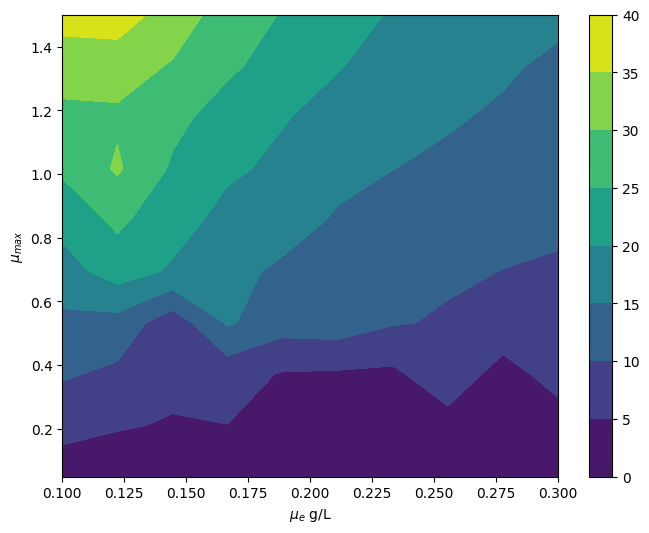

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
mue_conc = np.linspace(0.05, 1.5, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(muX_concs, mue_conc)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_rl_simulation(
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
contour = ax.contourf(X, Y, Z, cmap="viridis")  # Change colormap if desired
plt.colorbar(contour, ax=ax)  # Add a colorbar for reference

# Add plot labels and title
ax.set_xlabel(r'$\mu_e$ g/L')
ax.set_ylabel(r'$\mu_{max}$')

plt.show() 